# Interpolation and Attribute-Specific editing

## Loading repository and enviroment

Before start do not forget to choose gpu runtime (Runtime -> Change runtime type -> T4 GPU)

In [2]:
import sys
sys.path.append("/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN")
from envs import actenv_jupyter, change_exp_dir
actenv_jupyter(cuda_version="12.9", gcc_version="11", clear_cache=False)

# https://github.com/MedMNIST/MedMNIST/blob/main/on_medmnist_plus.md


[actenv_jupyter] CUDA_HOME=/usr/local/cuda-12.9
[actenv_jupyter] TORCH_CUDA_ARCH_LIST=8.0
[actenv_jupyter] CXX=/usr/bin/g++-11 | CC=/usr/bin/gcc-11
[actenv_jupyter] Ready.


{'CUDA_HOME': '/usr/local/cuda-12.9',
 'TORCH_CUDA_ARCH_LIST': '8.0',
 'CC': '/usr/bin/gcc-11',
 'CXX': '/usr/bin/g++-11',
 'CUDAHOSTCXX': '/usr/bin/g++-11',
 'CXXFLAGS': '-std=c++17',
 'PATH_head': '/usr/local/cuda-12.9/bin:/home/ids/yuhe/anaconda3/envs/styleGANenv/bin:/home/ids/yuhe/.vscode-server/cli/servers/Stable-994fd12f8d3a5aa16f17d42c041e5809167e845a/server/bin/remote-cli',
 'LD_LIBRARY_PATH_head': '/usr/local/cuda-12.9/lib64:',
 'TORCH_CUDA_VERBOSE_BUILD': '1',
 'MAX_JOBS': '1'}

In [5]:
import pandas as pd
# label_dict = {
#     "0": "basophil",
#     "1": "eosinophil",
#     "2": "erythroblast",
#     "3": "immature granulocytes(myelocytes, metamyelocytes and promyelocytes)",
#     "4": "lymphocyte",
#     "5": "monocyte",
#     "6": "neutrophil",
#     "7": "platelet",
# },
data_name = "octmnist"
img_path = f"/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/{data_name}/{data_name}_224"

csv_path = f"/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/{data_name}/{data_name}_224.csv"

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print(df.head(5))


#cp /home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/octmnist/octmnist_224_test/*    /home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/octmnist/octmnist_224/

Shape: (109308, 3)
   TRAIN  train0_0.png  0
0  TRAIN  train1_3.png  3
1  TRAIN  train2_3.png  3
2  TRAIN  train3_3.png  3
3  TRAIN  train4_0.png  0
4  TRAIN  train5_3.png  3


Using labels: {0: 'choroidal neovascularization', 1: 'diabetic macular edema', 2: 'drusen', 3: 'normal'}


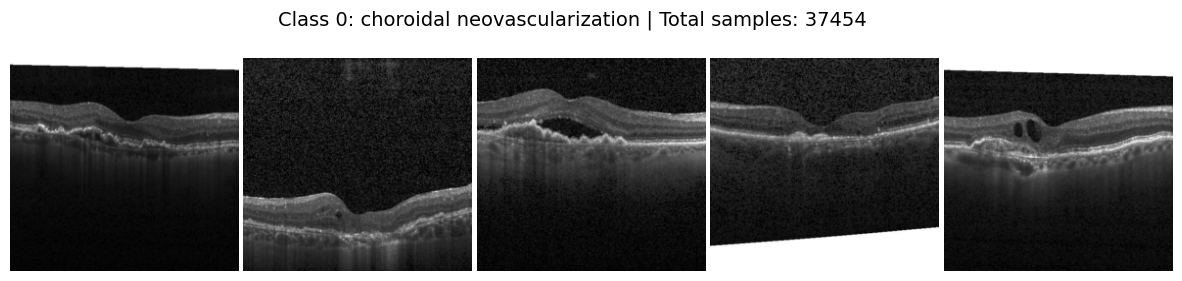

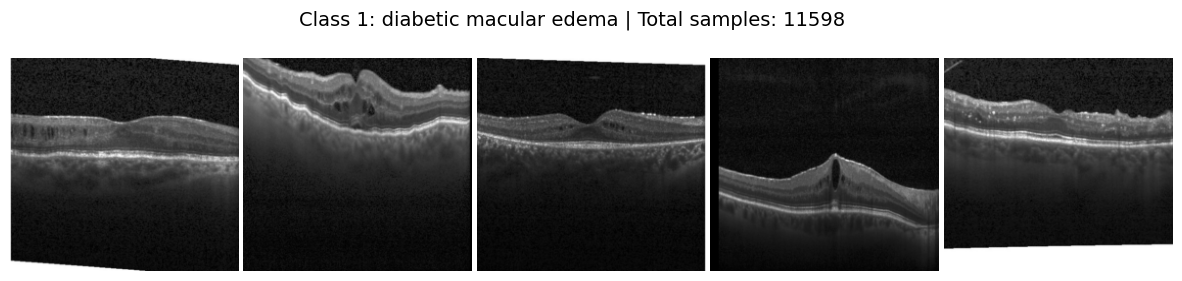

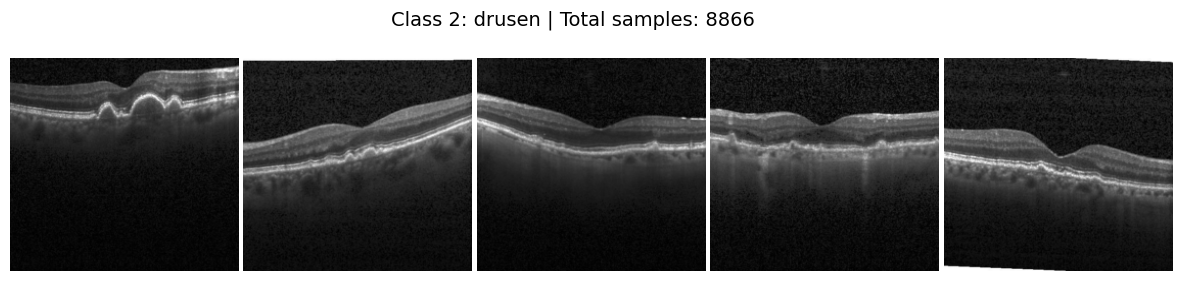

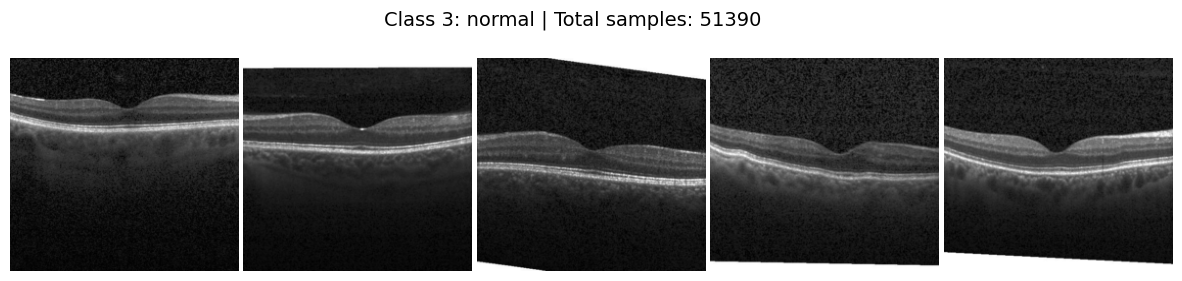

In [7]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
data_name = "octmnist"

img_path = f"/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/{data_name}/{data_name}_224"
csv_path = f"/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/{data_name}/{data_name}_224.csv"

# -------------------------------------------------
# LOAD LABELS FROM info.py (CORRECT WAY)
# -------------------------------------------------
medmnist_root = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/Medmnist/MedMNIST-main"
sys.path.append(medmnist_root)

from medmnist.info import INFO

dataset_info = INFO[data_name]
label_dict = {int(k): v for k, v in dataset_info["label"].items()}
task = dataset_info["task"]

assert task == "multi-class", f"{data_name} is not multi-class!"

print("Using labels:", label_dict)

# -------------------------------------------------
# LOAD CSV
# -------------------------------------------------
df = pd.read_csv(csv_path)

# count per class
class_counts = df.iloc[:, 2].value_counts().sort_index()

import numpy as np

imgs_per_class = 5
random_seed = 5  # for reproducibility

for class_id, class_name in label_dict.items():
    class_df_all = df[df.iloc[:, 2] == class_id]

    # skip empty classes (safety)
    if len(class_df_all) == 0:
        continue

    class_df = class_df_all.sample(
        n=min(imgs_per_class, len(class_df_all)),
        random_state=random_seed
    )

    fig, axes = plt.subplots(
        1, imgs_per_class,
        figsize=(15, 3),
        gridspec_kw={"wspace": 0.02}   # 关键：减小横向间距
    )

    # 如果 imgs_per_class=1 时，axes 不是 list，统一一下
    if imgs_per_class == 1:
        axes = [axes]

    fig.suptitle(
        f"Class {class_id}: {class_name} | Total samples: {class_counts.get(class_id, 0)}",
        fontsize=14
    )

    for ax, (_, row) in zip(axes, class_df.iterrows()):
        img_file = row.iloc[1]
        img_full_path = os.path.join(img_path, img_file)

        img = Image.open(img_full_path).convert("RGB")
        ax.imshow(img, aspect="auto")   # 关键：减少子图内部留白（别让 equal 限制）
        ax.axis("off")

    # 不要 tight_layout 自动帮你拉开间距，用 subplots_adjust 更可控
    fig.subplots_adjust(top=0.82, wspace=0.02)  # top 给标题留点空间
    plt.show()



In [69]:
import os
import shutil
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# --------------------
# CONFIG
# --------------------
data_name = "octmnist"
label_X = 3                # X domain label (e.g., normal=3; here 0 means class 0 is used for X)
labels_Y =  [0, 1, 2]            # Y domain labels (can be multi-class, e.g., [0, 1, 2])

img_path = f"/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/{data_name}/{data_name}_224"
csv_path = f"/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/{data_name}/{data_name}_224.csv"

train_ratio = 0.85
random_seed = 42

# Max number of images per domain (X or Y). Set to None to use the maximum feasible balanced amount.
n_samples_per_domain = None

save_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/{data_name}/split_x{label_X}_y{''.join(map(str,labels_Y))}/"

# --------------------
# LOAD CSV
# --------------------
df = pd.read_csv(csv_path)

# Safety check: X and Y labels should not overlap
if label_X in labels_Y:
    raise ValueError(f"label_X ({label_X}) should not be in labels_Y ({labels_Y}).")

# --------------------
# FILTER BY LABEL
# --------------------
df_X = df[df.iloc[:, 2] == label_X]
df_Y = {ly: df[df.iloc[:, 2] == ly] for ly in labels_Y}

print(f"X label {label_X} count: {len(df_X)}")
for ly in labels_Y:
    print(f"Y label {ly} count: {len(df_Y[ly])}")

# --------------------
# DECIDE BALANCED COUNTS
# --------------------
m = len(labels_Y)  # number of classes in Y

# Choose k samples per Y-class, subject to:
# 1) Each Y class must have at least k samples available
# 2) X must have at least m * k samples available
k_max = min([len(df_Y[ly]) for ly in labels_Y] + [len(df_X) // m])
if k_max <= 0:
    raise ValueError("Not enough samples to build balanced splits for the requested labels.")

total_per_domain = m * k_max  # total number of samples in X and in Y (X = Y)

# Optionally cap the total number of samples per domain (still keeping divisibility by m)
if n_samples_per_domain is not None:
    total_per_domain = min(total_per_domain, n_samples_per_domain)
    total_per_domain = (total_per_domain // m) * m
    k_max = total_per_domain // m

print(f"Using k={k_max} per Y-class, total X=Y={m * k_max}")

# --------------------
# SAMPLE X
# --------------------
df_X_s = df_X.sample(m * k_max, random_state=random_seed)
paths_X = df_X_s.iloc[:, 1].apply(lambda p: os.path.join(img_path, p)).values

# Split X
train_X, test_X = train_test_split(
    paths_X,
    train_size=train_ratio,
    random_state=random_seed,
    shuffle=True
)

# X labels (all the same)
train_X_labels = np.full(len(train_X), label_X, dtype=np.int64)
test_X_labels  = np.full(len(test_X),  label_X, dtype=np.int64)

# --------------------
# SAMPLE + SPLIT Y (class-wise to keep balance in train/test)
# --------------------
train_Y_parts, test_Y_parts = [], []
train_Ylab_parts, test_Ylab_parts = [], []

for ly in labels_Y:
    df_y_s = df_Y[ly].sample(k_max, random_state=random_seed)
    paths_y = df_y_s.iloc[:, 1].apply(lambda p: os.path.join(img_path, p)).values

    tr, te = train_test_split(
        paths_y,
        train_size=train_ratio,
        random_state=random_seed,
        shuffle=True
    )

    train_Y_parts.append(tr)
    test_Y_parts.append(te)

    # Matching labels for each path
    train_Ylab_parts.append(np.full(len(tr), ly, dtype=np.int64))
    test_Ylab_parts.append(np.full(len(te), ly, dtype=np.int64))

train_Y = np.concatenate(train_Y_parts, axis=0)
test_Y  = np.concatenate(test_Y_parts, axis=0)
train_Y_labels = np.concatenate(train_Ylab_parts, axis=0)
test_Y_labels  = np.concatenate(test_Ylab_parts, axis=0)

# Shuffle Y and Y labels together (important!)
rng = np.random.default_rng(random_seed)

perm = rng.permutation(len(train_Y))
train_Y, train_Y_labels = train_Y[perm], train_Y_labels[perm]

perm = rng.permutation(len(test_Y))
test_Y, test_Y_labels = test_Y[perm], test_Y_labels[perm]

# --------------------
# SANITY CHECK
# --------------------
print("Final sizes:")
print(" - train_X:", len(train_X))
print(" - test_X :", len(test_X))
print(" - train_Y:", len(train_Y))
print(" - test_Y :", len(test_Y))

assert len(train_X) + len(test_X) == len(train_Y) + len(test_Y), "X/Y total mismatch!"
assert (len(train_Y) + len(test_Y)) % m == 0, "Y total not divisible by number of Y classes!"
assert len(train_Y) == len(train_Y_labels) and len(test_Y) == len(test_Y_labels), "Y labels mismatch!"
assert len(train_X) == len(train_X_labels) and len(test_X) == len(test_X_labels), "X labels mismatch!"

# --------------------
# SAVE (NPY + CSV in the same folder)
# If save_dir exists, delete it first, then recreate it.
# --------------------
if os.path.exists(save_dir):
    shutil.rmtree(save_dir)
    print(f"Deleted existing directory: {save_dir}")
os.makedirs(save_dir, exist_ok=True)

# Save NPY files
np.save(os.path.join(save_dir, "train_X.npy"), train_X)
np.save(os.path.join(save_dir, "train_Y.npy"), train_Y)
np.save(os.path.join(save_dir, "test_X.npy"), test_X)
np.save(os.path.join(save_dir, "test_Y.npy"), test_Y)

# Save CSV file
df_splits = pd.concat([
    pd.DataFrame({"path": train_X, "label": train_X_labels, "domain": "X", "split": "train"}),
    pd.DataFrame({"path": test_X,  "label": test_X_labels,  "domain": "X", "split": "test"}),
    pd.DataFrame({"path": train_Y, "label": train_Y_labels, "domain": "Y", "split": "train"}),
    pd.DataFrame({"path": test_Y,  "label": test_Y_labels,  "domain": "Y", "split": "test"}),
], ignore_index=True)

df_splits.to_csv(os.path.join(save_dir, "splits.csv"), index=False)

print("Saved to:", save_dir)
print("Saved files:")
print(" - train_X.npy, test_X.npy, train_Y.npy, test_Y.npy")
print(" - splits.csv (columns: path,label,domain,split)")


X label 3 count: 51390
Y label 0 count: 37454
Y label 1 count: 11598
Y label 2 count: 8866
Using k=8866 per Y-class, total X=Y=26598
Final sizes:
 - train_X: 22608
 - test_X : 3990
 - train_Y: 22608
 - test_Y : 3990
Saved to: /home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/octmnist/split_x3_y012/
Saved files:
 - train_X.npy, test_X.npy, train_Y.npy, test_Y.npy
 - splits.csv (columns: path,label,domain,split)


Random seed: 12375


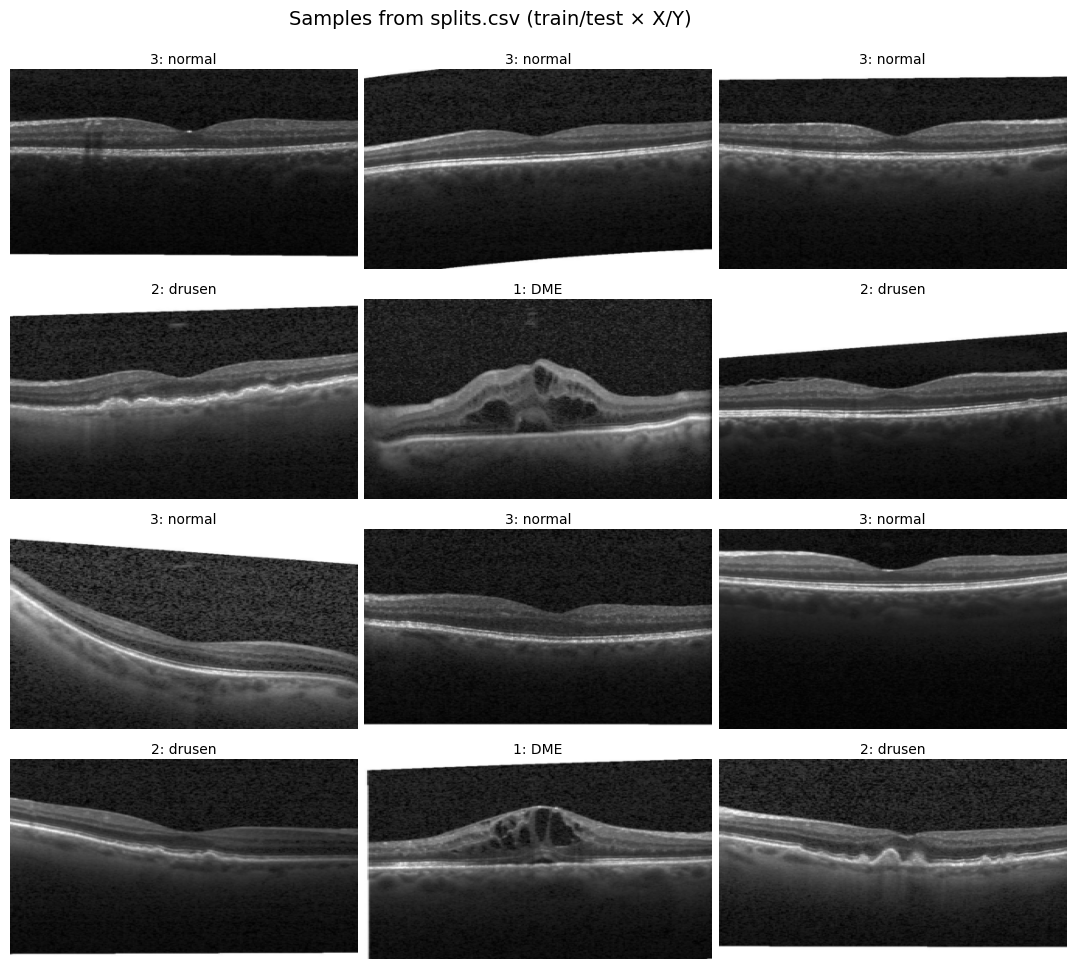

In [74]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def get_random_seed():
    seed = random.randint(0, 20000)
    print("Random seed:", seed)
    return seed

# --------------------
# CONFIG
# --------------------
imgs_per_row = 3
seed = get_random_seed()
random.seed(seed)

label_X = 3                 # X domain label (e.g., normal=3)
labels_Y = [0, 1, 2]         # Y domain labels (can be multi-class)

data_name = "octmnist"
medminist_path = "/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets/MedMNIST/"
split_name = f"split_x{label_X}_y{''.join(map(str, labels_Y))}"
split_dir = os.path.join(medminist_path, data_name, split_name)
csv_file = os.path.join(split_dir, "splits.csv")

# Label id -> name (optional; OCTMNIST has 4 fixed classes)
label_name_map = {
    0: "CNV",
    1: "DME",
    2: "drusen",
    3: "normal",
}

# --------------------
# LOAD SPLITS CSV
# --------------------
df = pd.read_csv(csv_file)

# We will visualize 4 rows: train_X, train_Y, test_X, test_Y
rows = [("train", "X"), ("train", "Y"), ("test", "X"), ("test", "Y")]

# --------------------
# VISUALIZATION (tighter layout + per-image titles)
# --------------------
n_rows = len(rows)
fig, axes = plt.subplots(
    n_rows, imgs_per_row,
    figsize=(12, 10),
    gridspec_kw={"wspace": 0.02, "hspace": 0.15}
)

# Make sure axes is always 2D (handles edge cases where n_rows=1 or imgs_per_row=1)
axes = np.atleast_2d(axes)

for r, (split, domain) in enumerate(rows):
    sub = df[(df["split"] == split) & (df["domain"] == domain)]

    # If this subset has fewer than imgs_per_row samples, just take all
    n_pick = min(imgs_per_row, len(sub))
    picked = sub.sample(n=n_pick, random_state=seed)

    for c in range(imgs_per_row):
        ax = axes[r, c]
        ax.axis("off")

        if c >= n_pick:
            continue

        row = picked.iloc[c]
        img_path = row["path"]
        lab = int(row["label"])
        lab_name = label_name_map.get(lab, str(lab))

        img = Image.open(img_path).convert("RGB")
        ax.imshow(img, aspect="auto")

        # Per-image label shown above each image
        ax.set_title(f"{lab}: {lab_name}", fontsize=10, pad=4)

        # Row label on the left
        if c == 0:
            ax.set_ylabel(f"{split}_{domain}", fontsize=12, rotation=0, labelpad=40, va="center")

fig.suptitle("Samples from splits.csv (train/test × X/Y)", fontsize=14)
fig.subplots_adjust(left=0.10, right=0.98, top=0.92, bottom=0.03, wspace=0.02, hspace=0.15)
plt.show()
